In [197]:
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.config import * 
from winogender_contextuality.modeling.prompting import *
import ast
#from winogender_contextuality.modeling.meta_prompting import *
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Constants

In [2]:
model_names = ['gpt', 'phi', 'gemma', 'llama1b', 'llama8b', 'qwen']

### Experiment Measurements

In [3]:
gpt_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5_wp_k40.ndjson")
max_gpt = max([x["index"] for x in gpt_wp])
f"{len(gpt_wp)} Measuremenents"

'579200 Measuremenents'

In [4]:
phi_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_phi-4_0.5_wp_k40.ndjson")
max_phi = max([x["index"] for x in phi_wp])
f"{len(phi_wp)} Measuremenents"

'507354 Measuremenents'

In [5]:
gemma_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gemma-3-12b-it_0.5_wp_k40.ndjson")
max_gemma = max([x["index"] for x in gemma_wp])
f"{len(gemma_wp)} Measuremenents"

'426124 Measuremenents'

In [6]:
llama1b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1331141225.ndjson")
max_llama1b = max([x["index"] for x in llama1b_wp])
f"{len(llama1b_wp)} Measuremenents"

'1158400 Measuremenents'

In [7]:
llama8b_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.1-8B-Instruct_0.5_wp_k40.ndjson")
max_llama8b = max([x["index"] for x in llama8b_wp])
f"{len(llama8b_wp)} Measuremenents"

'724000 Measuremenents'

In [8]:
qwen_wp = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen2.5-7B-Instruct_0.5_wp_k40.ndjson")
max_qwen = max([x["index"] for x in qwen_wp])
f"{len(qwen_wp)} Measuremenents"

'694400 Measuremenents'

In [9]:
results_list = [gpt_wp, phi_wp, gemma_wp, llama1b_wp, llama8b_wp, qwen_wp]

### Metaprompting Measurements

In [160]:
questions = ['anaphora', 'pos', 'other_gender']

In [162]:
gpt_meta = load_ndjson(INTERIM_DATA_DIR / 
                       "metaprompting_gpt-oss-20b_0.5_1037130326.ndjson")

In [163]:
phi_meta = load_ndjson(INTERIM_DATA_DIR / 
                       "metaprompting_phi-4_0.5_0856130326.ndjson")

In [166]:
gemma_meta = load_ndjson(INTERIM_DATA_DIR / 
                         "metaprompting_gemma-3-12b-it_0.5_1511150326.ndjson")

In [167]:
llama1b_meta = load_ndjson(INTERIM_DATA_DIR / 
                           "metaprompting_Llama-3.2-1B-Instruct_0.5_1907110326.ndjson")

In [168]:
llama8b_meta = load_ndjson(INTERIM_DATA_DIR / 
                           "metaprompting_Llama-3.1-8B-Instruct_0.5_1858110326.ndjson")

In [169]:
qwen_meta = load_ndjson(INTERIM_DATA_DIR / 
                        "metaprompting_Qwen2.5-7B-Instruct_0.5_1106130326.ndjson" )

In [170]:
models_meta = [gpt_meta, phi_meta, gemma_meta, llama1b_meta, llama8b_meta, qwen_meta]

# Functions

In [171]:
def get_meta_index(idx: int,
                   lst: list[dict]):

    """
    :param idx: pair index
    :param lst: a list of MetaQA objects or equivalent dictionaries 

    Filters list of responses by index.
    """

    return [x for x in lst if x['index'] == idx]
    
def get_meta_question(q: str,
                      lst: list[dict]):

    """
    :param q: string key of the question
    :param lst: a list of MetaQA objects or equivalent dictionaries 

    Filters list of responses by question.
    """

    return [x for x in lst if x['question'] == q]

In [186]:
def get_meta_scores(lst: list[dict],
                   questions: list[str] = ['anaphora', 'pos', 'other_gender']):
    
    dic = {idx: {} for idx in range(60)}


    for idx in range(60):
        for q in questions:
            responses = get_meta_question(q, get_meta_index(idx, lst))
            n_correct = len([r for r in responses if r['response'] == r['answer'].replace("the ", "").replace("a ", "").strip().lower()])
            dic[idx][q] = n_correct/(8*10) # as a fraction of best possible (including errors)

    return dic
        

In [187]:
def get_average_meta(dic: dict):

    response_arr = []
    for idx, dic in dic.items():
        response_arr.append(list(dic.values()))
    response_arr = np.array(response_arr)

    return np.mean(response_arr, axis=0)

In [188]:
def plot_response_dict(response_d):
    # Extract data
    indices = list(response_d.keys())
    categories = list(next(iter(response_d.values())).keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))  # color per category

    # Create plot
    plt.figure(figsize=(8, 5))

    for cat, color in zip(categories, colors):
        vals = [response_d[i][cat] for i in indices]
        plt.scatter(indices, vals, color=color, label=cat, s=50, alpha=0.7)

    # Labels and style
    plt.xlabel('Index')
    plt.ylabel('Score')
    plt.title('Response Dictionary Scatter Plot')
    plt.xticks(indices)
    plt.ylim(0, 1)
    plt.legend(title='Category')
    plt.grid(True, linestyle='--', alpha=0.6)

In [189]:
def get_valid_unprimed_counts(data: list[Measurement],
                              max_index: int = 181
                             ) -> dict:
    unprimed_counts = {sent_idx: {} for sent_idx in range(2 * max_index+1)}
    for idx in tqdm(range(max_index)): 
    
        # [m,f] option order 
        fwd_ct_mf = len(get_pnoun_order(0, get_single_sentences(get_sent_order([0,1], get_index(idx, data))))) 
        bwd_ct_mf = len(get_pnoun_order(0, get_single_sentences(get_sent_order([1,0], get_index(idx, data))))) 
    
        fwd_ct_fm = len(get_pnoun_order(1, get_single_sentences(get_sent_order([0,1], get_index(idx, data))))) 
        bwd_ct_fm = len(get_pnoun_order(1, get_single_sentences(get_sent_order([1,0], get_index(idx, data))))) 
    
        unprimed_counts[2*idx]["mf"] = fwd_ct_mf
        unprimed_counts[2*idx + 1]["mf"] = fwd_ct_mf
        unprimed_counts[2*idx]["fm"] = fwd_ct_fm
        unprimed_counts[2*idx + 1]["fm"] = fwd_ct_fm
    return unprimed_counts

In [176]:
def get_valid_primed_counts(data: list[Measurement],
                            pnoun: int,
                            max_index: int = 181
    ) -> dict:

    """
    :param data:
    :param pnoun: 0 for masc, 1 for fem
    :param max_index: 
    """
    
    p_primed_counts = {sent_idx: {} for sent_idx in range(2 * max_index+1)}
    for idx in tqdm(range(max_index)): 
    
        # [m,f] option order 
        fwd_ct_mf = len(get_pnoun_order(0, get_filled_pnoun(pnoun, get_sent_order([0,1], get_index(idx, data))))) 
        bwd_ct_mf = len(get_pnoun_order(0, get_filled_pnoun(pnoun, get_sent_order([1,0], get_index(idx, data))))) 
    
        fwd_ct_fm = len(get_pnoun_order(1, get_filled_pnoun(pnoun, get_sent_order([0,1], get_index(idx, data)))))
        bwd_ct_fm = len(get_pnoun_order(1, get_filled_pnoun(pnoun, get_sent_order([1,0], get_index(idx, data))))) 
    
        p_primed_counts[2*idx]["mf"] = fwd_ct_mf
        p_primed_counts[2*idx + 1]["mf"] = fwd_ct_mf
        p_primed_counts[2*idx]["fm"] = fwd_ct_fm
        p_primed_counts[2*idx + 1]["fm"] = fwd_ct_fm
        
    return p_primed_counts

# Counting Valid Responses

In [100]:
unprimed_model_counts = []
for model in results_list:
    unprimed_model_counts.append(get_valid_unprimed_counts(model))

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

In [127]:
masc_primed_model_counts = []
for model in results_list:
    masc_primed_model_counts.append(get_valid_primed_counts(model, 0))

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

In [128]:
fem_primed_model_counts = []
for model in results_list:
    fem_primed_model_counts.append(get_valid_primed_counts(model, 1))

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

  0%|          | 0/181 [00:00<?, ?it/s]

In [132]:
un_m_count = 0
for idx, d in list(unprimed_model_counts[-1].items())[:-1]:
    un_m_count += d['mf']
    un_f_count += d['fm']
    
un_m_count,int(.25*(len(qwen_wp)))

(173600, 173600)

In [133]:
un_m_count = 0
un_f_count = 0

masc_m_count = 0
masc_f_count = 0

fem_m_count = 0
fem_f_count = 0

for idx, d in list(unprimed_model_counts[-1].items())[:-1]:
    un_m_count += d['mf']
    un_f_count += d['fm']

for idx, d in list(masc_primed_model_counts[-1].items())[:-1]:
    masc_m_count += d['mf']
    masc_f_count += d['fm']

for idx, d in list(fem_primed_model_counts[-1].items())[:-1]:
    fem_m_count += d['mf']
    fem_f_count += d['fm']


un_m_count, un_f_count, masc_m_count*2/un_m_count, masc_f_count*2/un_m_count, fem_m_count*2/un_m_count, fem_f_count*2/un_m_count

(173600, 173600, 1.0, 1.0, 1.0, 1.0)

In [135]:
ratio_un_m = []
ratio_un_f = []
ratio_masc_m = []
ratio_masc_f = []
ratio_fem_m = []
ratio_fem_f = []

for i,model in enumerate(results_list):
    total_measurements_per_setting = int(.25*(len(model)))
    
    un_m_count = 0
    un_f_count = 0
    
    masc_m_count = 0
    masc_f_count = 0
    
    fem_m_count = 0
    fem_f_count = 0
    
    for idx, d in list(unprimed_model_counts[i].items())[:-1]:
        un_m_count += d['mf']
        un_f_count += d['fm']
    
    for idx, d in list(masc_primed_model_counts[i].items())[:-1]:
        masc_m_count += d['mf']
        masc_f_count += d['fm']
    
    for idx, d in list(fem_primed_model_counts[i].items())[:-1]:
        fem_m_count += d['mf']
        fem_f_count += d['fm']
    
    ratio_un_m.append(f"{un_m_count}/{total_measurements_per_setting}")
    ratio_un_f.append(f"{un_f_count}/{total_measurements_per_setting}")
    ratio_masc_m.append(f"{masc_m_count}/{int(.5*total_measurements_per_setting)}")
    ratio_masc_f.append(f"{masc_f_count}/{int(.5*total_measurements_per_setting)}")
    ratio_fem_m.append(f"{fem_m_count}/{int(.5*total_measurements_per_setting)}")
    ratio_fem_f.append(f"{fem_f_count}/{int(.5*total_measurements_per_setting)}")

In [136]:
counts_df = pd.DataFrame()

counts_df['name'] = model_names
counts_df['Unprimed MF Order'] = ratio_un_m 
counts_df['Unprimed FM Order'] = ratio_un_f
counts_df['Masc Primed MF Order'] = ratio_masc_m
counts_df['Masc Primed FM Order'] = ratio_masc_f
counts_df['Fem Primed MF Order'] = ratio_fem_m
counts_df['Fem Primed FM Order'] = ratio_fem_f

In [137]:
counts_df

,name,Unprimed MF Order,Unprimed FM Order,Masc Primed MF Order,Masc Primed FM Order,Fem Primed MF Order,Fem Primed FM Order
0,gpt,144800/144800,144800/144800,72400/72400,72400/72400,72400/72400,72400/72400
1,phi,126966/126838,126860/126838,63324/63419,63256/63419,63316/63419,63178/63419
2,gemma,107170/106531,106800/106531,53500/53265,53396/53265,53476/53265,53238/53265
3,llama1b,271802/289600,276970/289600,107902/144800,96856/144800,108460/144800,101688/144800
4,llama8b,181000/181000,181000/181000,90500/90500,90500/90500,90500/90500,90500/90500
5,qwen,173600/173600,173600/173600,86800/86800,86800/86800,86800/86800,86800/86800


In [158]:
missing = 0
for idx, d in list(unprimed_model_counts[2].items())[:-1]:
    remainder = d['mf'] % 100
    if remainder != 0:
        missing += (100 - remainder)
missing

30

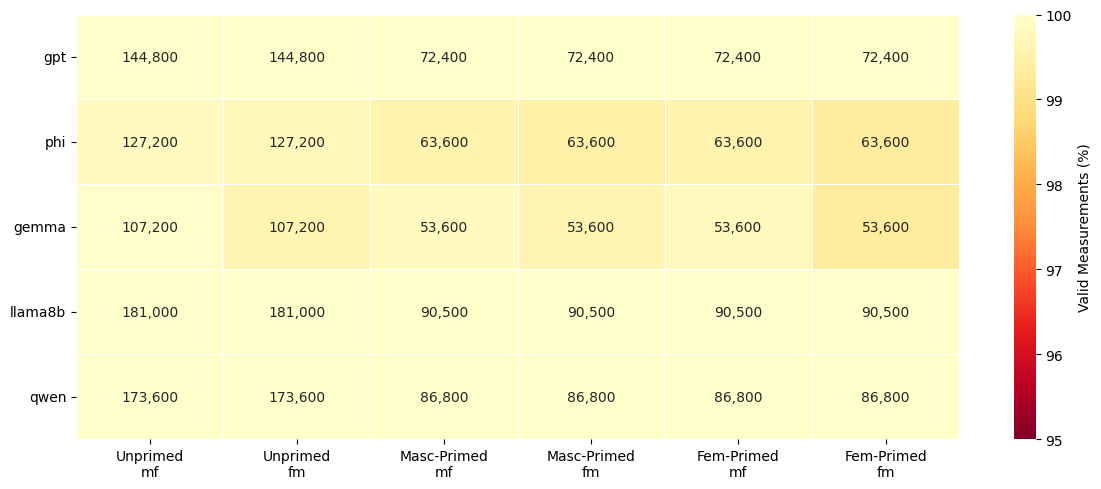

In [203]:
# --- Data ---
models = ["gpt", "phi", "gemma",  "llama8b", "qwen"] #

columns = pd.MultiIndex.from_tuples([
    ("Unprimed", "mf"), ("Unprimed", "fm"),
    ("Masc-Primed", "mf"), ("Masc-Primed", "fm"),
    ("Fem-Primed", "mf"), ("Fem-Primed", "fm"),
])

numerators = np.array([
    [144800, 144800, 72400, 72400, 72400, 72400],
    [126966, 126860, 63324, 63256, 63316, 63178],
    [107170, 106800, 53500, 53396, 53476, 53238],
    #[271802, 276970, 107902, 96856, 108460, 101688],
    [181000, 181000, 90500, 90500, 90500, 90500],
    [173600, 173600, 86800, 86800, 86800, 86800],
])

denominators = np.array([
    [144800, 144800, 72400, 72400, 72400, 72400],
    [127200, 127200, 63600, 63600, 63600, 63600],
    [107200, 107200, 53600, 53600, 53600, 53600],
    #[289600, 289600, 144800, 144800, 144800, 144800],
    [181000, 181000, 90500, 90500, 90500, 90500],
    [173600, 173600, 86800, 86800, 86800, 86800],
])

# Percentage for color
percentages = numerators / denominators * 100

# Flatten multi-index columns into single-level labels for display
flat_columns = [f"{cond}\n{order}" for cond, order in columns]

df_pct = pd.DataFrame(percentages, index=models, columns=flat_columns)
df_denom = pd.DataFrame(denominators, index=models, columns=flat_columns)

# Format denominator labels with commas
annot_labels = df_denom.map(lambda x: f"{int(x):,}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    df_pct,
    annot=annot_labels,
    fmt="s",
    cmap="YlOrRd_r",
    vmin=95,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Valid Measurements (%)"},
    ax=ax,
)

ax.set_ylabel("")
#ax.set_title("Valid Measurements by Model, Condition, and Order", fontsize=14, pad=12)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
#plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Counting Correct Responses

# Metaprompting Scores 

In [190]:
for model, model_name in zip(models_meta, model_names):
    scores = get_meta_scores(model)
    average = get_average_meta(scores)

    print(f"{model_name}: {average}")

gpt: [0.61729167 1.         0.849375  ]
phi: [0.74104167 1.         0.91145833]
gemma: [0.7425     1.         0.73041667]
llama1b: [0.495625   0.299375   0.63604167]
llama8b: [0.5825     0.93604167 0.95916667]
qwen: [0.44708333 0.99375    0.363125  ]
